In [1]:
import os
import commot as ct
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from anndata import AnnData
sc.logging.print_header() 
print(f"squidpy=={sq.__version__}")

scanpy==1.10.4 anndata==0.11.4 umap==0.5.3 numpy==1.26.4 scipy==1.13.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.9 pynndescent==0.5.13
squidpy==1.6.5


In [2]:
# Create anndata from 10x output  

path = os.path.expanduser("~/Desktop/LGG HPX/1. Data/3. Spatial Transcriptomics/Tirosh/IDHm BWH24_astro")
h5_path = os.path.join(path, "filtered_feature_bc_matrix.h5")
print(os.path.exists(h5_path)) 

adata = sq.read.visium(path = path, 
                       counts_file = 'filtered_feature_bc_matrix.h5', 
                       load_images = True) 

True


In [3]:
# Fixing the non-unique gene names 

adata.var_names_make_unique() 

In [4]:
!pip show commot

Name: commot
Version: 0.0.3
Summary: Cell-cell communications inference for spatial transcriptomics data via optimal transport.
Home-page: UNKNOWN
Author: 
Author-email: 
License: MIT License
Location: /opt/miniconda3/envs/spatial-env/lib/python3.10/site-packages
Requires: anndata, importlib-metadata, karateclub, leidenalg, networkx, numpy, pandas, plotly, pot, pysal, python-igraph, python-louvain, scanpy, scikit-learn
Required-by: 


In [5]:
# Basic preprocessing 

sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

In [6]:
# Specify ligand-receptor pairs 

df_ligrec = pd.DataFrame([['EGFR', 'HBEGF', 'EGF_pathway']], columns = ['ligand', 'receptor', 'pathway']) 
df_ligrec['ligand'] = df_ligrec['ligand'].str.upper()
df_ligrec['receptor'] = df_ligrec['receptor'].str.upper()

adata.var_names = adata.var_names.str.upper()

In [7]:
# Constructing cell-cell communication networks with a spatial distance constraint of 250µm 

adata.var_names_make_unique() 
print(adata.var_names.is_unique) 
ct.tl.spatial_communication(adata, 
                            database_name = 'user_database', 
                            df_ligrec = df_ligrec, 
                            dis_thr = 250, 
                            heteromeric = True, 
                            pathway_sum = True) 

True


In [8]:
print(list(adata.obsm.keys())) 
print(adata.obsm['commot-user_database-sum-sender'].columns)
print(adata.obsm['commot-user_database-sum-receiver'].columns)

['spatial', 'commot-user_database-sum-sender', 'commot-user_database-sum-receiver']
Index(['s-EGFR-HBEGF', 's-total-total', 's-EGF_pathway'], dtype='object')
Index(['r-EGFR-HBEGF', 'r-total-total', 'r-EGF_pathway'], dtype='object')


In [9]:
# Define output directory

output_dir = os.path.expanduser("~/Desktop/LGG HPX/2. Analysis/1-3. Analysis (Spatial)/6. COMMOT/plots")
os.makedirs(output_dir, exist_ok = True) 

Text(0.5, 1.0, 'Receiver')

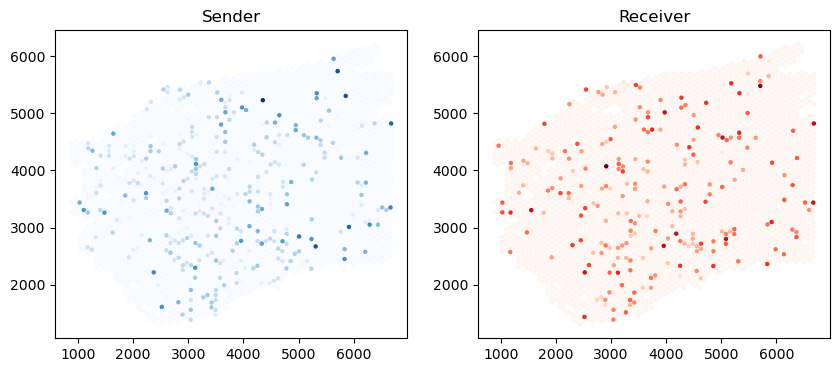

In [10]:
# Visualize the amount of sent and received signal 

pts = adata.obsm['spatial']
s = adata.obsm['commot-user_database-sum-sender']['s-EGFR-HBEGF']
r = adata.obsm['commot-user_database-sum-receiver']['r-EGFR-HBEGF']
fig, ax = plt.subplots(1,2, figsize = (10,4))
ax[0].scatter(pts[:,0], pts[:,1], c = s, s = 5, cmap = 'Blues')
ax[0].set_title('Sender')
ax[1].scatter(pts[:,0], pts[:,1], c = r, s = 5, cmap = 'Reds')
ax[1].set_title('Receiver') 

In [11]:
ct.tl.communication_direction(adata, database_name = 'user_database', lr_pair = ('EGFR','HBEGF'), k=5) 

In [12]:
print([k for k in adata.obsm.keys() if 'sender_vf' in k])

['commot_sender_vf-user_database-EGFR-HBEGF']


In [13]:
adata.obsm['commot-user_database-sum-sender']
adata.obsm['commot-user_database-sum-receiver'] 

,r-EGFR-HBEGF,r-total-total,r-EGF_pathway
AAACAAGTATCTCCCA-1,0.000000,0.000000,0.000000
AAACAATCTACTAGCA-1,0.000000,0.000000,0.000000
AAACAGAGCGACTCCT-1,0.000000,0.000000,0.000000
AAACAGTGTTCCTGGG-1,0.000000,0.000000,0.000000
AAACATTTCCCGGATT-1,0.000000,0.000000,0.000000
...,...,...,...
TTGTTCAGTGTGCTAC-1,0.000000,0.000000,0.000000
TTGTTGTGTGTCAAGA-1,0.565875,0.565875,0.565875
TTGTTTCACATCCAGG-1,0.000000,0.000000,0.000000
TTGTTTGTATTACACG-1,0.000000,0.000000,0.000000


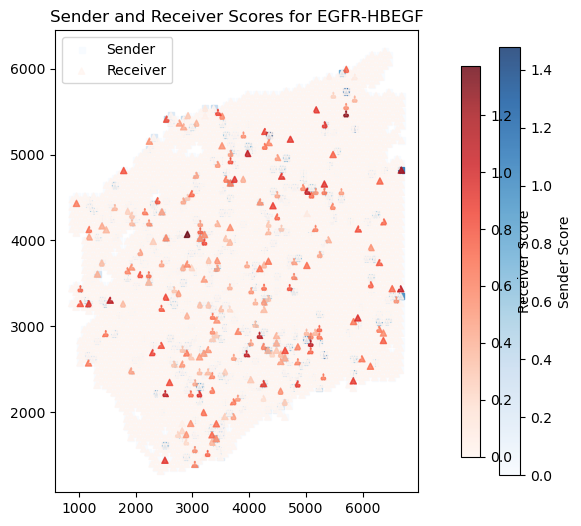

In [14]:
# Plot sender and receiver togather 

pts = adata.obsm['spatial']
s = adata.obsm['commot-user_database-sum-sender']['s-EGFR-HBEGF']
r = adata.obsm['commot-user_database-sum-receiver']['r-EGFR-HBEGF']

fig, ax = plt.subplots(figsize=(6, 6))

sc1 = ax.scatter(pts[:, 0], pts[:, 1], c = s, cmap = 'Blues', marker = 's', s = 20, alpha = 0.8, label = 'Sender', zorder = 2)
sc2 = ax.scatter(pts[:, 0], pts[:, 1], c = r, cmap = 'Reds', marker = '^', s = 20, alpha = 0.8, label = 'Receiver', zorder = 3)
ax.set_title('Sender and Receiver Scores for EGFR-HBEGF')
ax.legend()

cbar1 = plt.colorbar(sc1, ax = ax, fraction = 0.046, pad = 0.04)
cbar1.set_label('Sender Score')
cbar2 = plt.colorbar(sc2, ax = ax, fraction = 0.046, pad = 0.1)
cbar2.set_label('Receiver Score')
plt.savefig(os.path.join(output_dir, "EGFR_HBEGF_sender_receiver_shapes.pdf"), format = 'pdf', dpi = 300, bbox_inches = 'tight')

plt.show()

In [15]:
# Custom color palette 

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap 

colors_s = ['#d7e5b7', '#78a516', '#446300'] 
custom_cmap_s = LinearSegmentedColormap.from_list('my_cmap', colors_s) 
colors_r = ['#f7d0e2', '#C95792', '#7C4585'] 
custom_cmap_r = LinearSegmentedColormap.from_list('my_cmap', colors_r) 

<Axes: >

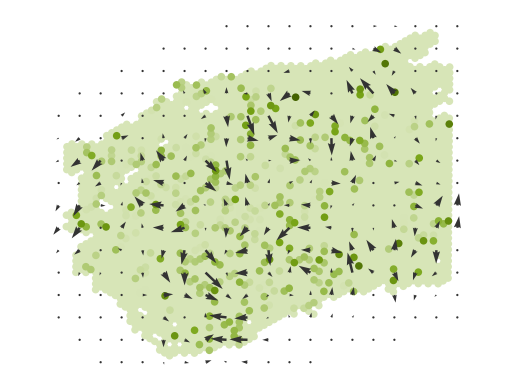

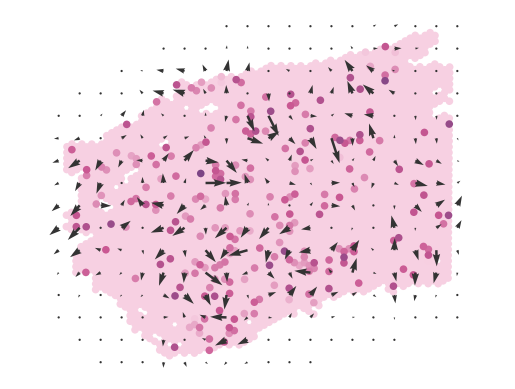

In [16]:
# Visualize signaling directions in a grid 

ct.pl.plot_cell_communication(adata, 
                              database_name = 'user_database', 
                              lr_pair = ('EGFR','HBEGF'), 
                              plot_method = 'grid', 
                              background_legend = True, 
                              scale = 0.00001, 
                              ndsize = 30, 
                              grid_density = 0.4, 
                              summary = 'sender', 
                              background = 'summary', 
                              clustering = 'leiden', 
                              cmap = custom_cmap_s, 
                              normalize_v = True, 
                              normalize_v_quantile = 0.995, 
                             filename = os.path.join(output_dir, "BWH24_EGFR_HBEGF_sender_plot.pdf")) 

ct.pl.plot_cell_communication(adata, 
                              database_name = 'user_database', 
                              lr_pair = ('EGFR','HBEGF'), 
                              plot_method = 'grid', 
                              background_legend = True, 
                              scale = 0.00001, 
                              ndsize = 30, 
                              grid_density = 0.4, 
                              summary = 'receiver', 
                              background = 'summary', 
                              clustering = 'leiden', 
                              cmap = custom_cmap_r, 
                              normalize_v = True, 
                              normalize_v_quantile = 0.995, 
                             filename = os.path.join(output_dir, "BWH24_EGFR_HBEGF_receiver_plot.pdf")) 

<Axes: >

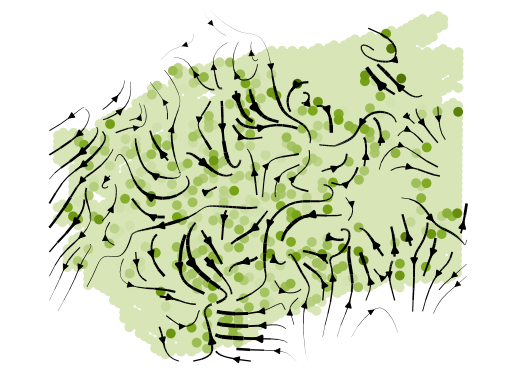

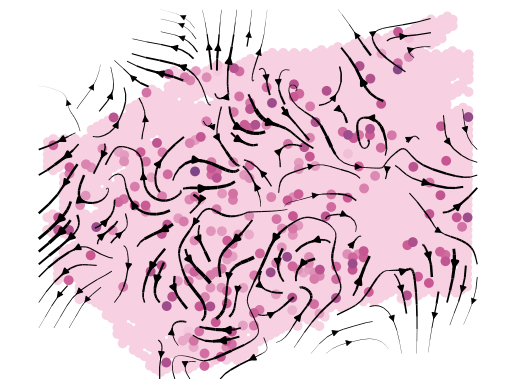

In [18]:
# Visualize signaling directions in a stream 

ct.pl.plot_cell_communication(adata, 
                              database_name = 'user_database', 
                              lr_pair = ('EGFR','HBEGF'), 
                              plot_method = 'stream', 
                              background_legend = True, 
                              scale = 0.00001, 
                              ndsize = 50, 
                              grid_density = 0.4, 
                              summary = 'sender', 
                              background = 'summary', 
                              clustering = 'leiden', 
                              cmap = custom_cmap_s, 
                              arrow_color = 'black', 
                              stream_density = 1.0, 
                              stream_linewidth = 2, 
                              normalize_v = False, 
                              normalize_v_quantile = 0.995, 
                             filename = os.path.join(output_dir, "BWH24_EGFR_HBEGF_sender_plot.png")) 

ct.pl.plot_cell_communication(adata, 
                              database_name = 'user_database', 
                              lr_pair = ('EGFR','HBEGF'), 
                              plot_method = 'stream', 
                              background_legend = True, 
                              scale = 0.00001, 
                              ndsize = 50, 
                              grid_density = 0.4, 
                              summary = 'receiver', 
                              background = 'summary', 
                              clustering = 'leiden', 
                              cmap = custom_cmap_r, 
                              arrow_color = 'black', 
                              stream_density = 1.0, 
                              stream_linewidth = 2, 
                              normalize_v = False, 
                              normalize_v_quantile = 0.995, 
                             filename = os.path.join(output_dir, "BWH24_EGFR_HBEGF_receiver_plot.png")) 